In [1]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import START, END 
from langgraph.graph.state import StateGraph 
from langgraph.graph.message import add_messages 
from langgraph.prebuilt import ToolNode 
from langchain_core.tools import tool 
from langchain_core.messages import BaseMessage
import os 
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY']=os.getenv('LANGSMITH_API_KEY')
os.environ['LANGSMITH_TRACING']="true"

In [4]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000171C9C6CF90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000171C9DD0150>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [11]:
#Graph with tool call 
from langchain_core.tools import tool

@tool 
def add(a:float, b:float)->float:
    """add two number and return the sum"""
    return a+b
tools = [add]
tool_node = ToolNode([add])
llm_with_tools = llm.bind_tools([add])

def call_llm_model(state: State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

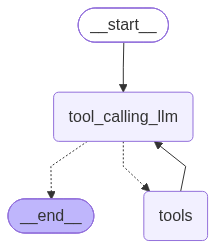

In [13]:
# Stategraph 
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node Definition 
def call_llm_model(state: State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", call_llm_model)
builder.add_node('tools',ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call --> tools_condition routes to tools 
    # if the latest message (result) from assistant is not a tool call --> tools_condition routes to END
    tools_condition
)
builder.add_edge('tools', "tool_calling_llm")
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
response = graph.invoke({"messages":"what is the addition of 2 and 3)"})

d:\Langraph\langG\Lib\site-packages\langsmith\client.py:656: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3d34-7ae3-ad37-345ef5aea087; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3d8a-78f0-8e98-ce94ffff1fee; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3d8d-7f80-af48-5601b442fc15


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3d8d-7f80-af48-5601b442fc15; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3ec3-7150-8d1b-2917d6800752; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3ec3-7150-8d1b-2917d6800752; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3d8a-78f0-8e98-ce94ffff1fee; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3ec5-7671-bb1a-313de451bb36; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3eca-7670-ac16-5bf108e968b1; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3eca-7670-ac16-5bf108e968b1; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id=019f8fda-3ec5-7671-bb1a-313de451bb36; trace=019f8fda-3d34-7ae3-ad37-345ef5aea087,id

In [15]:
response

{'messages': [HumanMessage(content='what is the addition of 2 and 3)', additional_kwargs={}, response_metadata={}, id='3a837f45-d662-43bf-b10e-aeed74846af2'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'q6wr80srk', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 231, 'total_tokens': 249, 'completion_time': 0.048807233, 'completion_tokens_details': None, 'prompt_time': 0.018472298, 'prompt_tokens_details': None, 'queue_time': 0.16109529, 'total_time': 0.067279531}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f8fda-3d8d-7f80-af48-5601b442fc15-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 3}, 'id': 'q6wr80srk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 231, 'out